# TRMM length_n_strength for El Nino year 2016 and La Nina year 2008

In [1]:
import os
import sys
import math
from pathlib import Path

import cftime
import numpy as np
import pandas as pd
import xarray as xr
from pyhdf.SD import SD, SDC

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────

TRMM_BASE = Path("/badc/trmm/data/TRMM_3B42")
OUT_DIR   = Path("./TRMM_length_n_strength")
OUT_DIR.mkdir(parents=True, exist_ok=True)

YEAR_START = 1998
YEAR_END   = 2019

YEAR_ElNino = 2016
YEAR_LaNina = 2008

varname  = "pr"
missval  = -999.0

In [3]:
# ── TRMM reader  ─────────────────────────────────────────────

def read_trmm_file(filepath):
    """
    Read a single TRMM 3B42 HDF4 file.
    Returns xarray DataArray (lat, lon) in mm/hr.
    """
    hdf    = SD(str(filepath), SDC.READ)
    precip = hdf.select("precipitation").get()   # (nlon=1440, nlat=400)
    precip = precip.T                            # → (400, 1440)

    lat = np.arange(-49.875, 49.876, 0.25)      # 400 points
    lon = np.arange(-179.875, 179.876, 0.25)    # 1440 points

    da = xr.DataArray(precip, dims=["lat", "lon"],
                      coords={"lat": lat, "lon": lon})

    fill_value = hdf.select("precipitation").attributes().get("_FillValue", -9999.9)
    da = da.where(da != fill_value)
    hdf.end()
    return da   # mm/hr


def load_trmm_daily_OLD(year_start, year_end, trmm_base):
    """
    Load TRMM 3B42 and return a daily DataArray (time, lat, lon) in mm/day.

    Each calendar day is assembled from up to 8 three-hourly files
    (03, 06, 09, 12, 15, 18, 21 UTC of that day + 00 UTC of the next day).
    The daily mean in mm/hr is then multiplied by 24 to give mm/day.
    """
    trmm_base  = Path(trmm_base)
    hours      = ["03", "06", "09", "12", "15", "18", "21", "00"]
    all_daily  = []
    all_dates  = []

    for year in range(year_start, year_end + 1):
        print(f"  Loading TRMM year {year}...")
        dates = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")

        for date in dates:
            doy     = date.strftime("%j")
            day_dir = trmm_base / str(year) / doy
            date_str = date.strftime("%Y%m%d")

            daily_slices = []
            for hr in hours:
                if hr == "00":
                    next_date = date + pd.Timedelta(days=1)
                    next_doy  = next_date.strftime("%j")
                    next_dir  = trmm_base / str(next_date.year) / next_doy
                    fname = next_dir / f"3B42.{next_date.strftime('%Y%m%d')}.{hr}.7.HDF"
                else:
                    fname = day_dir / f"3B42.{date_str}.{hr}.7.HDF"

                if not fname.exists():
                    continue
                try:
                    daily_slices.append(read_trmm_file(fname))
                except Exception as e:
                    print(f"    Error reading {fname.name}: {e}")

            if daily_slices:
                daily_mean = xr.concat(daily_slices, dim="slot").mean("slot")
                all_daily.append(daily_mean * 24.0)   # mm/hr → mm/day
                all_dates.append(date)

    if not all_daily:
        raise ValueError("No TRMM data found — check TRMM_BASE path.")

    time_index = pd.DatetimeIndex(all_dates)
    da = xr.concat(all_daily, dim=pd.Index(time_index, name="time"))
    da.attrs["units"] = "mm/day"
    return da

def load_trmm_daily_diagnostic_with_prints(year_start, year_end, trmm_base):
    trmm_base  = Path(trmm_base)
    hours      = ["03", "06", "09", "12", "15", "18", "21", "00"]
    all_daily  = []
    all_dates  = []

    for year in range(year_start, year_end + 1):
        print(f"  Loading TRMM year {year}...")
        dates = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")

        # ── DIAGNOSTIC: show what's actually in the first day's directory ──
        first_doy = dates[0].strftime("%j")
        first_dir = trmm_base / str(year) / first_doy
        print(f"  Checking directory: {first_dir}")
        if first_dir.exists():
            files = sorted(first_dir.iterdir())
            print(f"  Files found ({len(files)} total), first 5:")
            for f in files[:5]:
                print(f"    {f.name}")
        else:
            print(f"  !! Directory does not exist: {first_dir}")
            # Try listing the year directory to see what's there
            year_dir = trmm_base / str(year)
            if year_dir.exists():
                subdirs = sorted(year_dir.iterdir())
                print(f"  Year dir exists. Subdirs (first 5): {[d.name for d in subdirs[:5]]}")
            else:
                print(f"  !! Year directory also missing: {year_dir}")
        # ── END DIAGNOSTIC ──

        for date in dates:
            doy     = date.strftime("%j")
            day_dir = trmm_base / str(year) / doy
            date_str = date.strftime("%Y%m%d")

            daily_slices = []
            for hr in hours:
                if hr == "00":
                    next_date = date + pd.Timedelta(days=1)
                    next_doy  = next_date.strftime("%j")
                    next_dir  = trmm_base / str(next_date.year) / next_doy
                    fname = next_dir / f"3B42.{next_date.strftime('%Y%m%d')}.{hr}.7.HDF"
                else:
                    fname = day_dir / f"3B42.{date_str}.{hr}.7.HDF"

                if not fname.exists():
                    # ── DIAGNOSTIC: print first few misses to spot pattern ──
                    if date == dates[0]:
                        print(f"  Miss: {fname.name}")
                    continue
                try:
                    daily_slices.append(read_trmm_file(fname))
                except Exception as e:
                    print(f"    Error reading {fname.name}: {e}")

            if daily_slices:
                daily_mean = xr.concat(daily_slices, dim="slot").mean("slot")
                all_daily.append(daily_mean * 24.0)
                all_dates.append(date)

    if not all_daily:
        raise ValueError("No TRMM data found — check TRMM_BASE path.")

    time_index = pd.DatetimeIndex(all_dates)
    da = xr.concat(all_daily, dim=pd.Index(time_index, name="time"))
    da.attrs["units"] = "mm/day"
    return da

def load_trmm_daily(year_start, year_end, trmm_base):
    trmm_base  = Path(trmm_base)
    hours      = ["03", "06", "09", "12", "15", "18", "21", "00"]
    versions   = ["7", "7A", "7B"]      # tried in order; first match wins
    all_daily  = []
    all_dates  = []

    def find_trmm_file(directory, date_str, hr):
        """Return the first matching file across known version suffixes."""
        for ver in versions:
            p = directory / f"3B42.{date_str}.{hr}.{ver}.HDF"
            if p.exists():
                return p
        return None

    for year in range(year_start, year_end + 1):
        print(f"  Loading TRMM year {year}...")
        dates = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")

        for date in dates:
            doy      = date.strftime("%j")
            day_dir  = trmm_base / str(year) / doy
            date_str = date.strftime("%Y%m%d")

            daily_slices = []
            for hr in hours:
                if hr == "00":
                    next_date = date + pd.Timedelta(days=1)
                    next_doy  = next_date.strftime("%j")
                    next_dir  = trmm_base / str(next_date.year) / next_doy
                    fname = find_trmm_file(next_dir, next_date.strftime("%Y%m%d"), hr)
                else:
                    fname = find_trmm_file(day_dir, date_str, hr)

                if fname is None:
                    continue
                try:
                    daily_slices.append(read_trmm_file(fname))
                except Exception as e:
                    print(f"    Error reading {fname.name}: {e}")

            if daily_slices:
                daily_mean = xr.concat(daily_slices, dim="slot").mean("slot")
                all_daily.append(daily_mean * 24.0)
                all_dates.append(date)

    if not all_daily:
        raise ValueError("No TRMM data found — check TRMM_BASE path.")

    time_index = pd.DatetimeIndex(all_dates)
    da = xr.concat(all_daily, dim=pd.Index(time_index, name="time"))
    da.attrs["units"] = "mm/day"
    return da

In [4]:
#length_strength functions


# ── Get event properties function ────────────────────────

# def get_event_properties_old(values_1d, threshold=1):
#     wet = values_1d > threshold
#     durations, intensities, current_event = [], [], []
#     for val, is_wet in zip(values_1d, wet):
#         if is_wet:
#             current_event.append(val)
#         else:
#             if len(current_event) > 0:
#                 durations.append(len(current_event))
#                 intensities.append(np.mean(current_event))
#                 current_event = []
#     if len(current_event) > 0:
#         durations.append(len(current_event))
#         intensities.append(np.mean(current_event))
#     return np.array(durations), np.array(intensities)

def get_event_properties(values_1d, threshold=1):
    wet = values_1d > threshold
    durations, intensities, current_event = [], [], []
    for val, is_wet in zip(values_1d, wet):
        if is_wet:
            current_event.append(float(val))
        else:
            if len(current_event) > 0:
                durations.append(int(len(current_event)))    # ← explicit int
                intensities.append(float(np.mean(current_event)))
                current_event = []
    if len(current_event) > 0:
        durations.append(int(len(current_event)))            # ← explicit int
        intensities.append(float(np.mean(current_event)))
    return np.array(durations, dtype=np.int32), np.array(intensities, dtype=np.float32)

# ── Helper: compute durations & intensities from a (time, lat, lon) array ────

def compute_length_strength(da_mm, threshold=1):
    """
    Loop over every (lat, lon) grid point and collect
    wet spell durations and intensities.
    """
    nlat = da_mm.sizes["lat"]
    nlon = da_mm.sizes["lon"]
    all_durations, all_intensities = [], []

    for i in range(nlat):
        for j in range(nlon):
            ts = da_mm.isel(lat=i, lon=j).values
            ts = ts[np.isfinite(ts)]
            if len(ts) == 0:
                continue
            dur, inten = get_event_properties(ts, threshold=threshold)
            if len(dur) > 0:
                all_durations.append(dur)
                all_intensities.append(inten)

    return {
        "durations":   np.concatenate(all_durations),
        "intensities": np.concatenate(all_intensities),
    }

In [23]:
#Plotting function
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.cm import ScalarMappable
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# =========================================================
# HELPERS (keep outside the function — reusable)
# =========================================================

def pool_experiment(counts_all, exp):
    all_dur, all_int = [], []
    for model_name, exps in counts_all.items():
        if exp in exps:
            all_dur.append(exps[exp]["durations"])
            all_int.append(exps[exp]["intensities"])
    return np.concatenate(all_dur), np.concatenate(all_int)


def per_model_2d_hist(counts_all, exp, dur_bins, int_bins):
    hists = []
    for model_name, exps in counts_all.items():
        if exp not in exps:
            continue
        h, _, _ = np.histogram2d(
            exps[exp]["durations"],
            exps[exp]["intensities"],
            bins=[dur_bins, int_bins]
        )
        hists.append(h)
    return np.array(hists)


def compute_stippling(counts_all, exp_a, exp_b, dur_bins, int_bins, agree_frac):
    hists_a  = per_model_2d_hist(counts_all, exp_a, dur_bins, int_bins)
    hists_b  = per_model_2d_hist(counts_all, exp_b, dur_bins, int_bins)
    n_models = hists_a.shape[0]
    diff     = hists_a - hists_b
    pos_frac = (diff > 0).sum(axis=0) / n_models
    neg_frac = (diff < 0).sum(axis=0) / n_models
    return (pos_frac >= agree_frac) | (neg_frac >= agree_frac)


def compute_density(dur, inten, dur_bins, int_bins, sigma):
    h, _, _ = np.histogram2d(dur, inten, bins=[dur_bins, int_bins])
    h_smooth = gaussian_filter(h, sigma=sigma)
    xc = 0.5 * (dur_bins[:-1] + dur_bins[1:])
    yc = 0.5 * (int_bins[:-1] + int_bins[1:])
    X, Y = np.meshgrid(xc, yc, indexing="ij")
    return X, Y, h_smooth


def compute_density_pooled(counts_all, exp, dur_bins, int_bins, sigma):
    dur, inten = pool_experiment(counts_all, exp)
    return compute_density(dur, inten, dur_bins, int_bins, sigma)


def compute_density_ensemble_mean(counts_all, exp, dur_bins, int_bins, sigma):
    hists    = per_model_2d_hist(counts_all, exp, dur_bins, int_bins)
    h_mean   = hists.mean(axis=0)
    h_smooth = gaussian_filter(h_mean, sigma=sigma)
    xc = 0.5 * (dur_bins[:-1] + dur_bins[1:])
    yc = 0.5 * (int_bins[:-1] + int_bins[1:])
    X, Y = np.meshgrid(xc, yc, indexing="ij")
    return X, Y, h_smooth


# =========================================================
# MAIN PLOTTING FUNCTION
# =========================================================

def plot_wetspell_contours(
    counts_all,
    exp_a,
    exp_b,
    dur_max      = 40,
    int_max      = 70,
    smooth_sigma = 1.2,
    n_levels     = 8,
    n_levels_diff  = 16,   # control for difference panel
    linthresh    = 10,
    agree_frac   = 0.66,
    title        = None,
    save_path    = None,
    dpi          = 150,
):
    """
    Plot wet spell duration vs. intensity contour comparison.

    Parameters
    ----------
    counts_all   : dict  — {model: {exp: {"durations": ..., "intensities": ...}}}
    exp_a        : str   — name of experiment A (left panel, also minuend in diff)
    exp_b        : str   — name of experiment B (middle panel, subtrahend in diff)
    dur_max      : float — x-axis upper limit (days)
    int_max      : float — y-axis upper limit (mm/day)
    smooth_sigma : float — Gaussian smoothing sigma for contours
    n_levels     : int   — number of contour levels in panels 1 & 2
    linthresh    : float — SymLogNorm linear threshold for difference panel
    agree_frac   : float — fraction of models required for stippling (0–1)
    title        : str   — figure suptitle; auto-generated if None
    save_path    : str   — file path to save figure; skips saving if None
    dpi          : int   — output resolution
    """

    # ---- Bin definitions ----
    dur_bins_c = np.linspace(0, dur_max, 40)   # fine bins for smooth contours
    int_bins_c = np.linspace(0, int_max, 35)
    dur_bins_s = np.arange(0, dur_max + 1, 2)  # coarser bins for stippling
    int_bins_s = np.arange(0, int_max + 1, 5)

    # ---- Densities ----
    Xa, Ya, Ha = compute_density_pooled(
        counts_all, exp_a, dur_bins_c, int_bins_c, smooth_sigma)
    Xb, Yb, Hb = compute_density_pooled(
        counts_all, exp_b, dur_bins_c, int_bins_c, smooth_sigma)

    _, _, Ha_m = compute_density_ensemble_mean(
        counts_all, exp_a, dur_bins_c, int_bins_c, smooth_sigma)
    _, _, Hb_m = compute_density_ensemble_mean(
        counts_all, exp_b, dur_bins_c, int_bins_c, smooth_sigma)
    H_diff = Ha_m - Hb_m

    # ---- Contour levels ----
    vmax_ab    = np.percentile(np.concatenate([Ha.ravel(), Hb.ravel()]), 98)
    vmin_ab    = max(1, min(Ha[Ha > 0].min(), Hb[Hb > 0].min()))
    levels_ab  = np.logspace(np.log10(vmin_ab), np.log10(vmax_ab), n_levels)

    diff_abs_max = np.nanpercentile(np.abs(H_diff), 98)
    # levels_pos   = np.logspace(
    #     np.log10(max(0.1, linthresh)),
    #     np.log10(max(linthresh + 1, diff_abs_max)),
    #     n_levels_diff // 2        # ← was n_levels // 2
    # )
    # levels_diff = np.concatenate([-levels_pos[::-1], [0], levels_pos])

    # ---- Difference levels — fully manual ----
    levels_pos  = np.array([1, 2, 3, 4, 50, 100, 200, 500, 1000, 2000, 5000])
    levels_pos  = levels_pos[levels_pos <= diff_abs_max]   # drop anything beyond data range
    levels_neg  = -levels_pos[::-1]
    levels_diff = np.concatenate([levels_neg, [0], levels_pos])

    # # ---- Stippling ----
    # agree_mask   = compute_stippling(
    #     counts_all, exp_a, exp_b, dur_bins_s, int_bins_s, agree_frac)
    # mean_a_h     = per_model_2d_hist(
    #     counts_all, exp_a, dur_bins_s, int_bins_s).mean(axis=0)
    # mean_b_h     = per_model_2d_hist(
    #     counts_all, exp_b, dur_bins_s, int_bins_s).mean(axis=0)
    # stip_mask    = agree_mask & (np.abs(mean_a_h - mean_b_h) > 0)
    # dur_sc       = 0.5 * (dur_bins_s[:-1] + dur_bins_s[1:])
    # int_sc       = 0.5 * (int_bins_s[:-1] + int_bins_s[1:])
    # Xs, Ys       = np.meshgrid(dur_sc, int_sc, indexing="ij")

    # ---- Norms ----
    norm_ab   = LogNorm(vmin=vmin_ab, vmax=vmax_ab)
    # norm_diff = SymLogNorm(
    #     linthresh=linthresh, linscale=0.5,
    #     vmin=-diff_abs_max, vmax=diff_abs_max, base=10
    # )
    norm_diff = SymLogNorm(
        linthresh = 10,        # ← match your finest level
        linscale  = 0.5,
        vmin      = -diff_abs_max,
        vmax      =  diff_abs_max,
        base      = 10
    )

    # ---- Figure layout ----
    fig = plt.figure(figsize=(20, 6))
    gs  = gridspec.GridSpec(
        1, 5, figure=fig,
        width_ratios=[1, 1, 1, 0.05, 0.05],
        wspace=0.35
    )
    ax1      = fig.add_subplot(gs[0])
    ax2      = fig.add_subplot(gs[1], sharey=ax1)
    ax3      = fig.add_subplot(gs[2], sharey=ax1)
    cax_ab   = fig.add_subplot(gs[3])
    cax_diff = fig.add_subplot(gs[4])

    # ---- Panel 1: EXP_A ----
    cf1 = ax1.contourf(Xa, Ya, Ha, levels=levels_ab, extend="both",
                       cmap="YlOrRd", norm=norm_ab)
    ax1.contour(Xa, Ya, Ha, levels=levels_ab,
                colors="k", linewidths=0.5, alpha=0.4)
    ax1.set_title(f"{exp_a}\n(only 1 year)", fontsize=13)
    ax1.set_xlabel("Duration (days)", fontsize=12)
    ax1.set_ylabel("Mean Intensity (mm/day)", fontsize=12)
    ax1.set_xlim(0, dur_max);  ax1.set_xticks(np.arange(0, dur_max + 1, 10))
    ax1.set_ylim(0, int_max);  ax1.set_yticks(np.arange(0, int_max + 1, 10))
    ax1.tick_params(labelsize=11)
    ax1.grid(True, lw=0.4, alpha=0.5)

    # ---- Panel 2: EXP_B ----
    cf2 = ax2.contourf(Xb, Yb, Hb, levels=levels_ab, extend="both",
                       cmap="YlOrRd", norm=norm_ab)
    ax2.contour(Xb, Yb, Hb, levels=levels_ab,
                colors="k", linewidths=0.5, alpha=0.4)
    ax2.set_title(f"{exp_b}\n(only 1 year)", fontsize=13)
    ax2.set_xlabel("Duration (days)", fontsize=12)
    ax2.set_xlim(0, dur_max);  ax2.set_xticks(np.arange(0, dur_max + 1, 10))
    ax2.tick_params(labelleft=False, labelsize=11)
    ax2.grid(True, lw=0.4, alpha=0.5)

    # Shared colorbar panels 1 & 2
    cb_ab = fig.colorbar(cf2, cax=cax_ab, extend="both")
    cb_ab.set_label("Event count (log scale)", fontsize=10)
    cb_ab.ax.tick_params(labelsize=9, rotation=45)

    # ---- Panel 3: difference ----
    cf3 = ax3.contourf(Xa, Ya, H_diff, levels=levels_diff,
                       cmap="RdBu_r", norm=norm_diff, extend="both")
    ax3.contour(Xa, Ya, H_diff, levels=[0],
                colors="k", linewidths=5.0, alpha=0.4)
    # ax3.contour(Xa, Ya, H_diff, levels=[1],
    #             colors="k", linewidths=1, alpha=0.4)
    # ax3.scatter(Xs[stip_mask], Ys[stip_mask],
    #             s=8, c="k", marker=".", linewidths=0, alpha=0.7, zorder=5,
    #             label=f"≥{int(agree_frac * 100)}% model agreement")
    ax3.set_title(f"{exp_a} − {exp_b}\n(Tropics: 15S-15N)", fontsize=13)
    ax3.set_xlabel("Duration (days)", fontsize=12)
    ax3.set_xlim(0, dur_max);  ax3.set_xticks(np.arange(0, dur_max + 1, 10))
    ax3.tick_params(labelleft=False, labelsize=11)
    ax3.grid(True, lw=0.4, alpha=0.5)
    ax3.legend(loc="upper right", fontsize=9, markerscale=2)

    # Difference colorbar
    cb_diff = fig.colorbar(cf3, cax=cax_diff, extend="both")
    cb_diff.set_label(f"Δ event count\n({exp_a}−{exp_b})", fontsize=10)
    tick_vals = [-1000, -100, -linthresh, 0, linthresh, 100, 1000]
    tick_vals = [v for v in tick_vals
                 if -diff_abs_max <= v <= diff_abs_max]   # drop out-of-range
    cb_diff.set_ticks(tick_vals)
    cb_diff.set_ticklabels([f"{v:.0f}" for v in tick_vals])
    cb_diff.ax.tick_params(labelsize=9, rotation=45)

    # ---- Title & layout ----
    if title is None:
        title = f"Wet spell duration vs. intensity  |  {exp_a} vs {exp_b}"
    plt.suptitle(title, fontsize=14, y=1.02)

    plt.tight_layout()
    pos_ab   = cax_ab.get_position()
    pos_diff = cax_diff.get_position()
    cax_ab.set_position([pos_ab.x0 - 0.01,   pos_ab.y0,
                         pos_ab.width,         pos_ab.height])
    cax_diff.set_position([pos_diff.x0 + 0.01, pos_diff.y0,
                           pos_diff.width,      pos_diff.height])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.close(fig)
    return fig

In [24]:

# ── Tropical lat band (match your model analysis) ────────────────────────────

TROP_LAT_MIN = -15
TROP_LAT_MAX =  15
THRESHOLD    =  1    # mm/day

# ── El Niño ───────────────────────────────────────────────────────────────────

outfile_elnino = OUT_DIR / f"rain_length_and_strength_Annual_Tropics_TRMM_{YEAR_ElNino}.nc"

# if outfile_elnino.exists():
#     print(f"SKIP {outfile_elnino.name} — already exists")
#     # Load back
#     ds_en = xr.open_dataset(outfile_elnino)
#     data_elnino = {
#         "durations":   ds_en["durations"].values,
#         "intensities": ds_en["intensities"].values,
#     }
#     ds_en.close()

if outfile_elnino.exists():
    print(f"SKIP {outfile_elnino.name} — already exists")
    ds_en = xr.open_dataset(outfile_elnino, decode_times=False)   # ← key fix
    data_elnino = {
        "durations":   ds_en["durations"].values.astype("int32"),
        "intensities": ds_en["intensities"].values.astype("float32"),
    }
    ds_en.close()
else:
    print(f"\n{'='*60}\n  TRMM El Niño {YEAR_ElNino}\n{'='*60}")
    da_mm = load_trmm_daily(YEAR_ElNino, YEAR_ElNino, TRMM_BASE)
    da_mm = da_mm.transpose("time", "lat", "lon")
    da_tropics = da_mm.sel(lat=slice(TROP_LAT_MIN, TROP_LAT_MAX))

    print("  Computing wet spell properties...")
    data_elnino = compute_length_strength(da_tropics, threshold=THRESHOLD)

    # Save
    # xr.Dataset({
    #     "durations":   xr.Variable("events", data_elnino["durations"].astype("int32"),
    #                                attrs={"units": "days"}),
    #     "intensities": xr.Variable("events", data_elnino["intensities"],
    #                                attrs={"units": "mm/day"}),
    # }).to_netcdf(outfile_elnino)
    xr.Dataset({
        "durations":   xr.Variable("events",
                                   data_elnino["durations"],   # already int32 from above
                                   attrs={"units": "days"}),
        "intensities": xr.Variable("events",
                                   data_elnino["intensities"],
                                   attrs={"units": "mm/day"}),
    }).to_netcdf(outfile_elnino, encoding={
        "durations":   {"dtype": "int32"},
        "intensities": {"dtype": "float32"},
    })
    
    print(f"  ✓ Saved {outfile_elnino.name}  ({len(data_elnino['durations'])} events)")


# ── La Niña ───────────────────────────────────────────────────────────────────

outfile_lanina = OUT_DIR / f"rain_length_and_strength_Annual_Tropics_TRMM_{YEAR_LaNina}.nc"

if outfile_lanina.exists():
    print(f"SKIP {outfile_lanina.name} — already exists")
    ds_ln = xr.open_dataset(outfile_lanina, decode_times=False)   # ← key fix
    data_lanina = {
        "durations":   ds_ln["durations"].values.astype("int32"),
        "intensities": ds_ln["intensities"].values.astype("float32"),
    }
    ds_ln.close()
else:
    print(f"\n{'='*60}\n  TRMM La Niña {YEAR_LaNina}\n{'='*60}")
    da_mm = load_trmm_daily(YEAR_LaNina, YEAR_LaNina, TRMM_BASE)
    da_mm = da_mm.transpose("time", "lat", "lon")
    da_tropics = da_mm.sel(lat=slice(TROP_LAT_MIN, TROP_LAT_MAX))

    print("  Computing wet spell properties...")
    data_lanina = compute_length_strength(da_tropics, threshold=THRESHOLD)

    xr.Dataset({
        "durations":   xr.Variable("events",
                                   data_lanina["durations"], 
                                   attrs={"units": "days"}),
        "intensities": xr.Variable("events",
                                   data_lanina["intensities"],
                                   attrs={"units": "mm/day"}),
    }).to_netcdf(outfile_lanina, encoding={
        "durations":   {"dtype": "int32"},
        "intensities": {"dtype": "float32"},
    })
    print(f"  ✓ Saved {outfile_lanina.name}  ({len(data_lanina['durations'])} events)")


exp_elnino = str(YEAR_ElNino)
exp_lanina = str(YEAR_LaNina)

counts_all_trmm = {
    "TRMM": {
        exp_elnino: data_elnino,
        exp_lanina: data_lanina,
    }
}

SKIP rain_length_and_strength_Annual_Tropics_TRMM_2016.nc — already exists
SKIP rain_length_and_strength_Annual_Tropics_TRMM_2008.nc — already exists


In [25]:
# # Delete corrupted files
# for f in [outfile_elnino, outfile_lanina]:
#     if f.exists():
#         os.remove(f)
#         print(f"Deleted {f.name}")
counts_all_trmm

{'TRMM': {'2016': {'durations': array([1, 1, 1, ..., 6, 2, 1], shape=(8120904,), dtype=int32),
   'intensities': array([3.0514288, 1.0628572, 1.6800001, ..., 5.0685716, 2.3999996,
          1.2342856], shape=(8120904,), dtype=float32)},
  '2008': {'durations': array([ 2, 18, 16, ...,  1,  1,  1], shape=(8374256,), dtype=int32),
   'intensities': array([ 8.057142 , 25.31238  , 12.700714 , ...,  6.4800005, 52.01143  ,
           4.0457144], shape=(8374256,), dtype=float32)}}}

In [26]:
dur_raw = data_elnino["durations"]
print(f"dtype:   {dur_raw.dtype}")
print(f"min:     {dur_raw.min()}")
print(f"max:     {dur_raw.max()}")
print(f"first 5: {dur_raw[:5]}")

dtype:   int32
min:     1
max:     366
first 5: [1 1 1 1 3]


In [27]:
# def fix_durations(data):
#     dur = data["durations"]
    
#     print(f"  Raw dtype: {dur.dtype}, min: {dur.min()}, max: {dur.max()}")
    
#     if np.issubdtype(dur.dtype, np.timedelta64):
#         # Proper timedelta64 — convert to days
#         dur_days = (dur / np.timedelta64(1, 'D')).astype("int32")
    
#     elif np.issubdtype(dur.dtype, np.integer) and dur.max() > 1_000_000:
#         # Integers but suspiciously large → stored as nanoseconds
#         dur_days = (dur.astype("int64") // 86_400_000_000_000).astype("int32")
    
#     else:
#         # Already sensible integer days
#         dur_days = dur.astype("int32")
    
#     print(f"  Fixed dur: min={dur_days.min()}, max={dur_days.max()}")
    
#     return {
#         "durations":   dur_days,
#         "intensities": data["intensities"].astype("float32"),
#     }

# # Sanity check
# for exp, label in [(exp_elnino, "El Niño"), (exp_lanina, "La Niña")]:
#     d = counts_all_trmm["TRMM"][exp]
#     print(f"{label} — dur: {d['durations'].min()}–{d['durations'].max()} days  "
#           f"| int: {d['intensities'].min():.1f}–{d['intensities'].max():.1f} mm/day  "
#           f"| n_events: {len(d['durations'])}")

Saved → TRMM_length_n_strength/wetspell_TRMM_2016_vs_2008.png


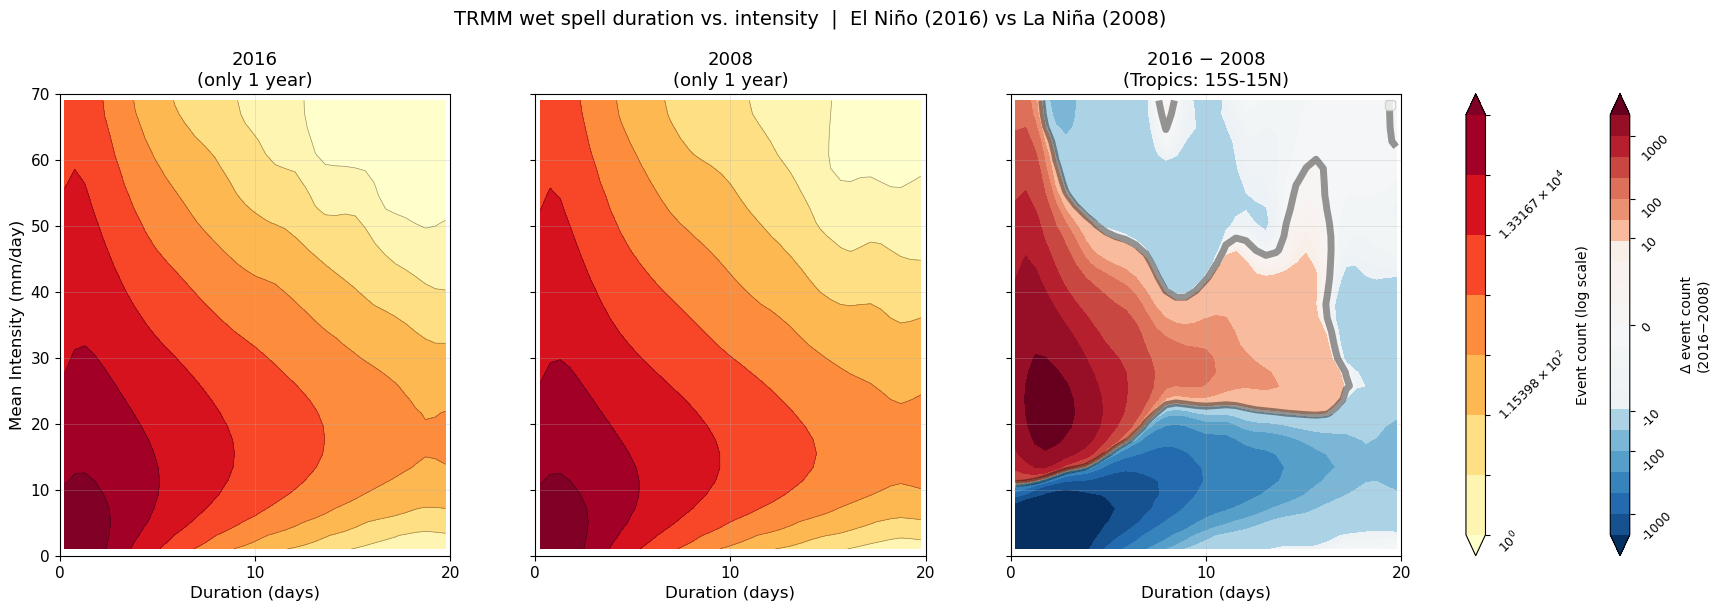

In [28]:
# ── Plot ──────────────────────────────────────────────────────────────────────

plot_wetspell_contours(
    counts_all_trmm,
    exp_a        = exp_elnino,          # El Niño — left panel
    exp_b        = exp_lanina,          # La Niña — middle panel
    dur_max      = 20,                  # TRMM years are short; reduce if needed
    int_max      = 70,
    smooth_sigma = 1.2,
    n_levels     = 8,
    linthresh    = 10,
    agree_frac   = 0.66,               # only 1 "model" so stippling won't fire
    title        = f"TRMM wet spell duration vs. intensity  |  El Niño ({YEAR_ElNino}) vs La Niña ({YEAR_LaNina})",
    save_path    = str(OUT_DIR / f"wetspell_TRMM_{YEAR_ElNino}_vs_{YEAR_LaNina}.png"),
    dpi          = 150,
)